In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=35c6b4af2eb67afd8b6ca621e4172efade6ae6a1b7eaffbee3b4a274184cba87
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [4]:
from torch.utils.data import DataLoader

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.datasets import STL10
from torchvision.models import resnet18, ResNet18_Weights

from torch.utils.data import DataLoader  # ← THIS WAS MISSING

import matplotlib.pyplot as plt
import numpy as np
import random

In [7]:
weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()

train_ds = STL10(root="./data", split="train", download=True, transform=preprocess)
test_ds  = STL10(root="./data", split="test",  download=True, transform=preprocess)

print(len(train_ds), len(test_ds))
print(train_ds.classes)

100%|██████████| 2.64G/2.64G [00:56<00:00, 46.9MB/s]


5000 8000
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [9]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)

In [10]:
x, y = next(iter(train_loader))
print(x.shape, y.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64])


In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [14]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params: 5130


In [15]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

In [16]:
num_epochs = 5
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc = 0
best_path = "best_resnet18_stl10.pt"

for epoch in range(num_epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), best_path)

    print(f"Epoch {epoch+1}: Train Loss={tr_loss:.4f}, Train Acc={tr_acc:.4f}, Test Loss={te_loss:.4f}, Test Acc={te_acc:.4f}")

print("Best test acc:", best_acc)

Epoch 1: Train Loss=0.9923, Train Acc=0.7534, Test Loss=0.4093, Test Acc=0.9137
Epoch 2: Train Loss=0.3526, Train Acc=0.9196, Test Loss=0.2752, Test Acc=0.9321
Epoch 3: Train Loss=0.2580, Train Acc=0.9330, Test Loss=0.2341, Test Acc=0.9359
Epoch 4: Train Loss=0.2173, Train Acc=0.9440, Test Loss=0.2135, Test Acc=0.9385
Epoch 5: Train Loss=0.1920, Train Acc=0.9484, Test Loss=0.1980, Test Acc=0.9424
Best test acc: 0.942375


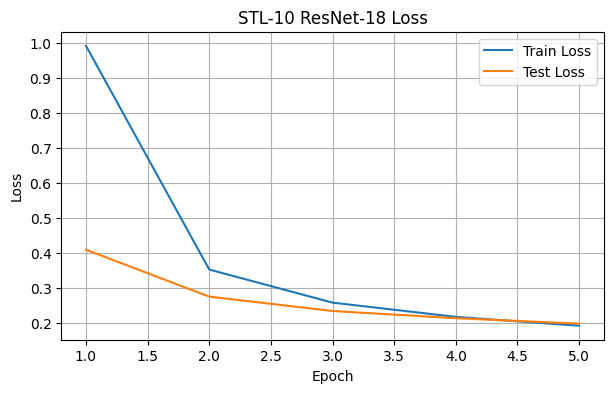

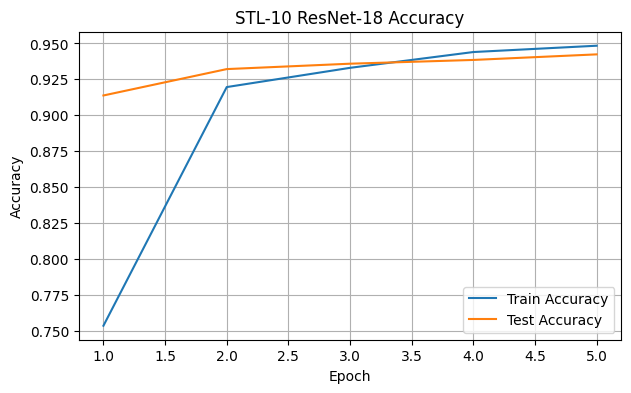

In [17]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("STL-10 ResNet-18 Loss")
plt.legend()
plt.grid(True)
plt.savefig("stl10_resnet_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["test_acc"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("STL-10 ResNet-18 Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("stl10_resnet_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load(best_path, map_location=device))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
display_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_display_ds = STL10(
    root="./data",
    split="test",
    download=True,
    transform=display_tf
)

In [20]:
correct_samples, incorrect_samples = [], []

with torch.no_grad():
    for idx in range(len(test_ds)):
        x, y = test_ds[idx]
        pred = model(x.unsqueeze(0).to(device)).argmax(1).item()

        if pred == y and len(correct_samples) < 2:
            raw_img, _ = test_display_ds[idx]
            correct_samples.append((idx, raw_img, y, pred))

        if pred != y and len(incorrect_samples) < 2:
            raw_img, _ = test_display_ds[idx]
            incorrect_samples.append((idx, raw_img, y, pred))

        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

print(len(correct_samples), len(incorrect_samples))

2 2


In [22]:
!pip install grad-cam

In [23]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [29]:
for p in model.parameters():
    p.requires_grad = True

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def generate_cam_overlay(img_tensor, target_class):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = (img[c] - mean[c]) / std[c]

    grayscale_cam = cam(
        input_tensor=img.unsqueeze(0).to(device),
        targets=[ClassifierOutputTarget(target_class)]
    )[0]

    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = np.clip(rgb_img, 0, 1)
    cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return rgb_img, cam_img

In [31]:
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def generate_cam_overlay(img_tensor, target_class):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = (img[c] - mean[c]) / std[c]

    grayscale_cam = cam(
        input_tensor=img.unsqueeze(0).to(device),
        targets=[ClassifierOutputTarget(target_class)]
    )[0]

    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = np.clip(rgb_img, 0, 1)
    cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return rgb_img, cam_img

In [25]:
print(GradCAM)

<class 'pytorch_grad_cam.grad_cam.GradCAM'>


In [26]:
cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

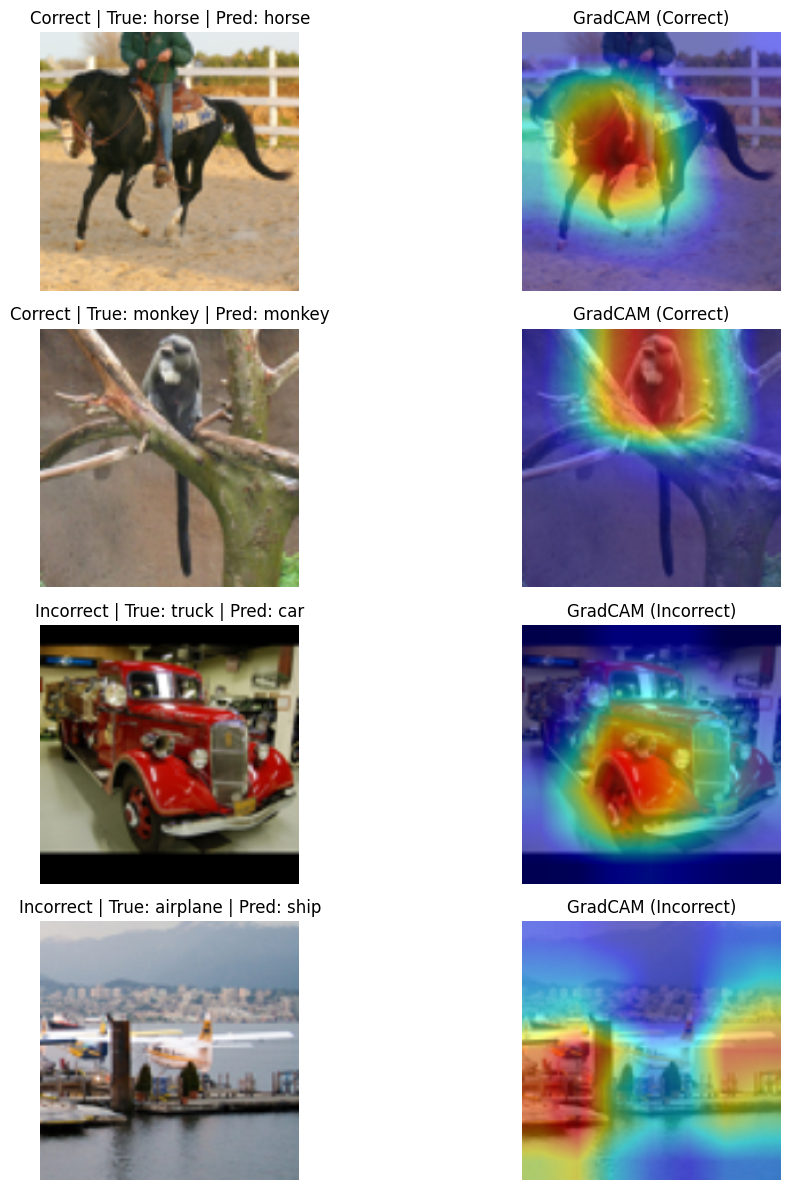

In [32]:
samples = [("Correct",) + s for s in correct_samples] + [("Incorrect",) + s for s in incorrect_samples]
class_names = test_ds.classes

plt.figure(figsize=(12, 12))

for i, (status, idx, img_tensor, true_label, pred_label) in enumerate(samples):
    rgb_img, cam_img = generate_cam_overlay(img_tensor, pred_label)

    # Original image
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(rgb_img)
    plt.title(f"{status} | True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    plt.axis("off")

    # GradCAM heatmap
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(cam_img)
    plt.title(f"GradCAM ({status})")
    plt.axis("off")

plt.tight_layout()
plt.show()